Done.
PyTorch device: cuda
  GPU: NVIDIA A100-SXM4-80GB
  VRAM: 85.1 GB
Raw shape: (908317, 14)
_LLCPWT_adjusted already present; using it directly.
Implausible BMI removed: 101
Clean shape:       (908216, 15)
Obese prevalence:  34.1%
Missing _INCOMG1:  300,232 (33.1%)
Missing _AGEG5YR:  0 (0.0%)
=== Chi-square: is missingness independent of observed variables? ===
p < 0.05 rejects MCAR

  _INCOMG1 missing X _SEX: chi2=62.6  p=0.0000  *** MCAR REJECTED
  _INCOMG1 missing X _RACEPRV: chi2=191.5  p=0.0000  *** MCAR REJECTED
  _INCOMG1 missing X _EDUCAG: chi2=718.8  p=0.0000  *** MCAR REJECTED
  _INCOMG1 missing X _STATE: chi2=18765.6  p=0.0000  *** MCAR REJECTED

  _AGEG5YR missing X _SEX: chi2=0.0  p=1.0000  OK
  _AGEG5YR missing X _RACEPRV: chi2=0.0  p=1.0000  OK
  _AGEG5YR missing X _EDUCAG: chi2=0.0  p=1.0000  OK
  _AGEG5YR missing X _STATE: chi2=0.0  p=1.0000  OK

Missingness indicators added to df
Trim threshold (p99): 1,053.4
Records trimmed:  9,081 (1.00%)
ESS before:       175,6

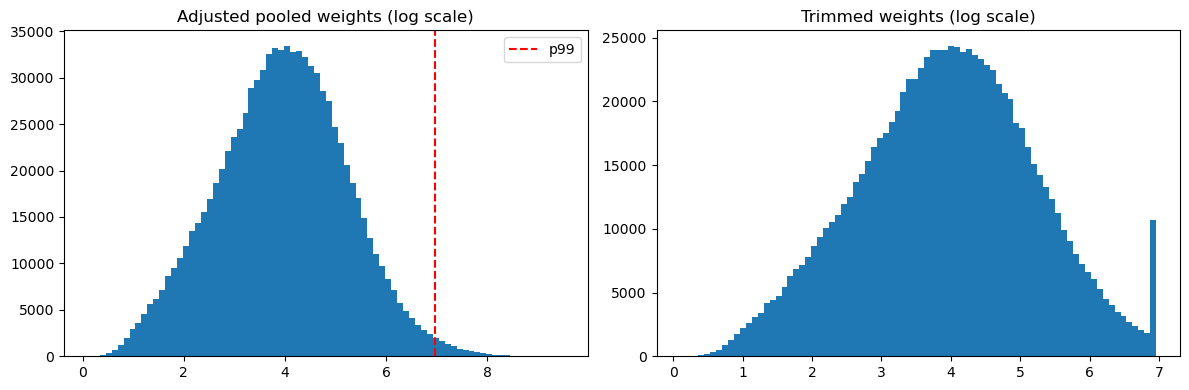

Stratified on _STATE x _RACEPRV jointly. Ensures every state x race combination appears in all three splits.
  train: 635,750 rows | obese 34.1% | states 54 | race groups 7
  val  : 136,233 rows | obese 33.9% | states 54 | race groups 7
  test : 136,233 rows | obese 34.2% | states 54 | race groups 7
Fitting 5 stochastic imputers on train set...
  m=1 done
  m=2 done
  m=3 done
  m=4 done
  m=5 done

Imputation complete. _INCOMG1 distribution (m=1, train):
_INCOMG1
1     34352
2     60611
3     87988
4    107630
5    180781
6    118550
7     45838
Name: count, dtype: int64
Input dim: 35
=== Training cell reliability ===
reliability
reliable      2130
unreliable    1428
marginal      1206
Name: count, dtype: int64

Total unique cells: 4,764


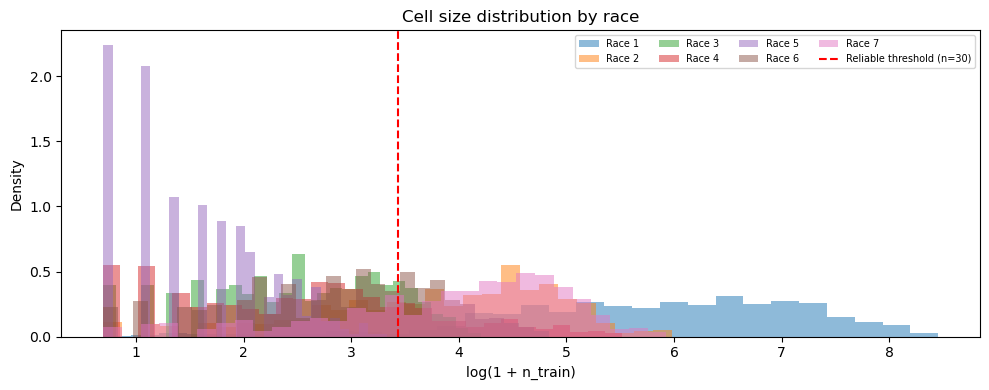

Reliable cells with target prevalences: 2,130
NUM_STATES: 54
Fitting frozen logistic base on 5 imputed datasets...
  m=1 | val AUC=0.6326 | val Brier=0.2119
  m=2 | val AUC=0.6325 | val Brier=0.2119
  m=3 | val AUC=0.6322 | val Brier=0.2119
  m=4 | val AUC=0.6324 | val Brier=0.2119
  m=5 | val AUC=0.6331 | val Brier=0.2118

=== Frozen Logistic Base - Test Set Metrics ===
  Weighted AUC:               0.6278
  Weighted Brier:             0.2146
  Predicted prevalence:       33.81%
  True prevalence:            34.15%
FrozenBaseStructuredNN(
  (state_emb): Embedding(54, 2)
  (state_head): Linear(in_features=2, out_features=1, bias=False)
  (cell_head): StructuredCellHead(
    (sex_emb): Embedding(3, 2, padding_idx=0)
    (age_emb): Embedding(14, 3, padding_idx=0)
    (race_emb): Embedding(8, 3, padding_idx=0)
    (educ_emb): Embedding(5, 2, padding_idx=0)
    (income_emb): Embedding(8, 2, padding_idx=0)
    (add_linear): Linear(in_features=12, out_features=1, bias=True)
    (inter_net): 

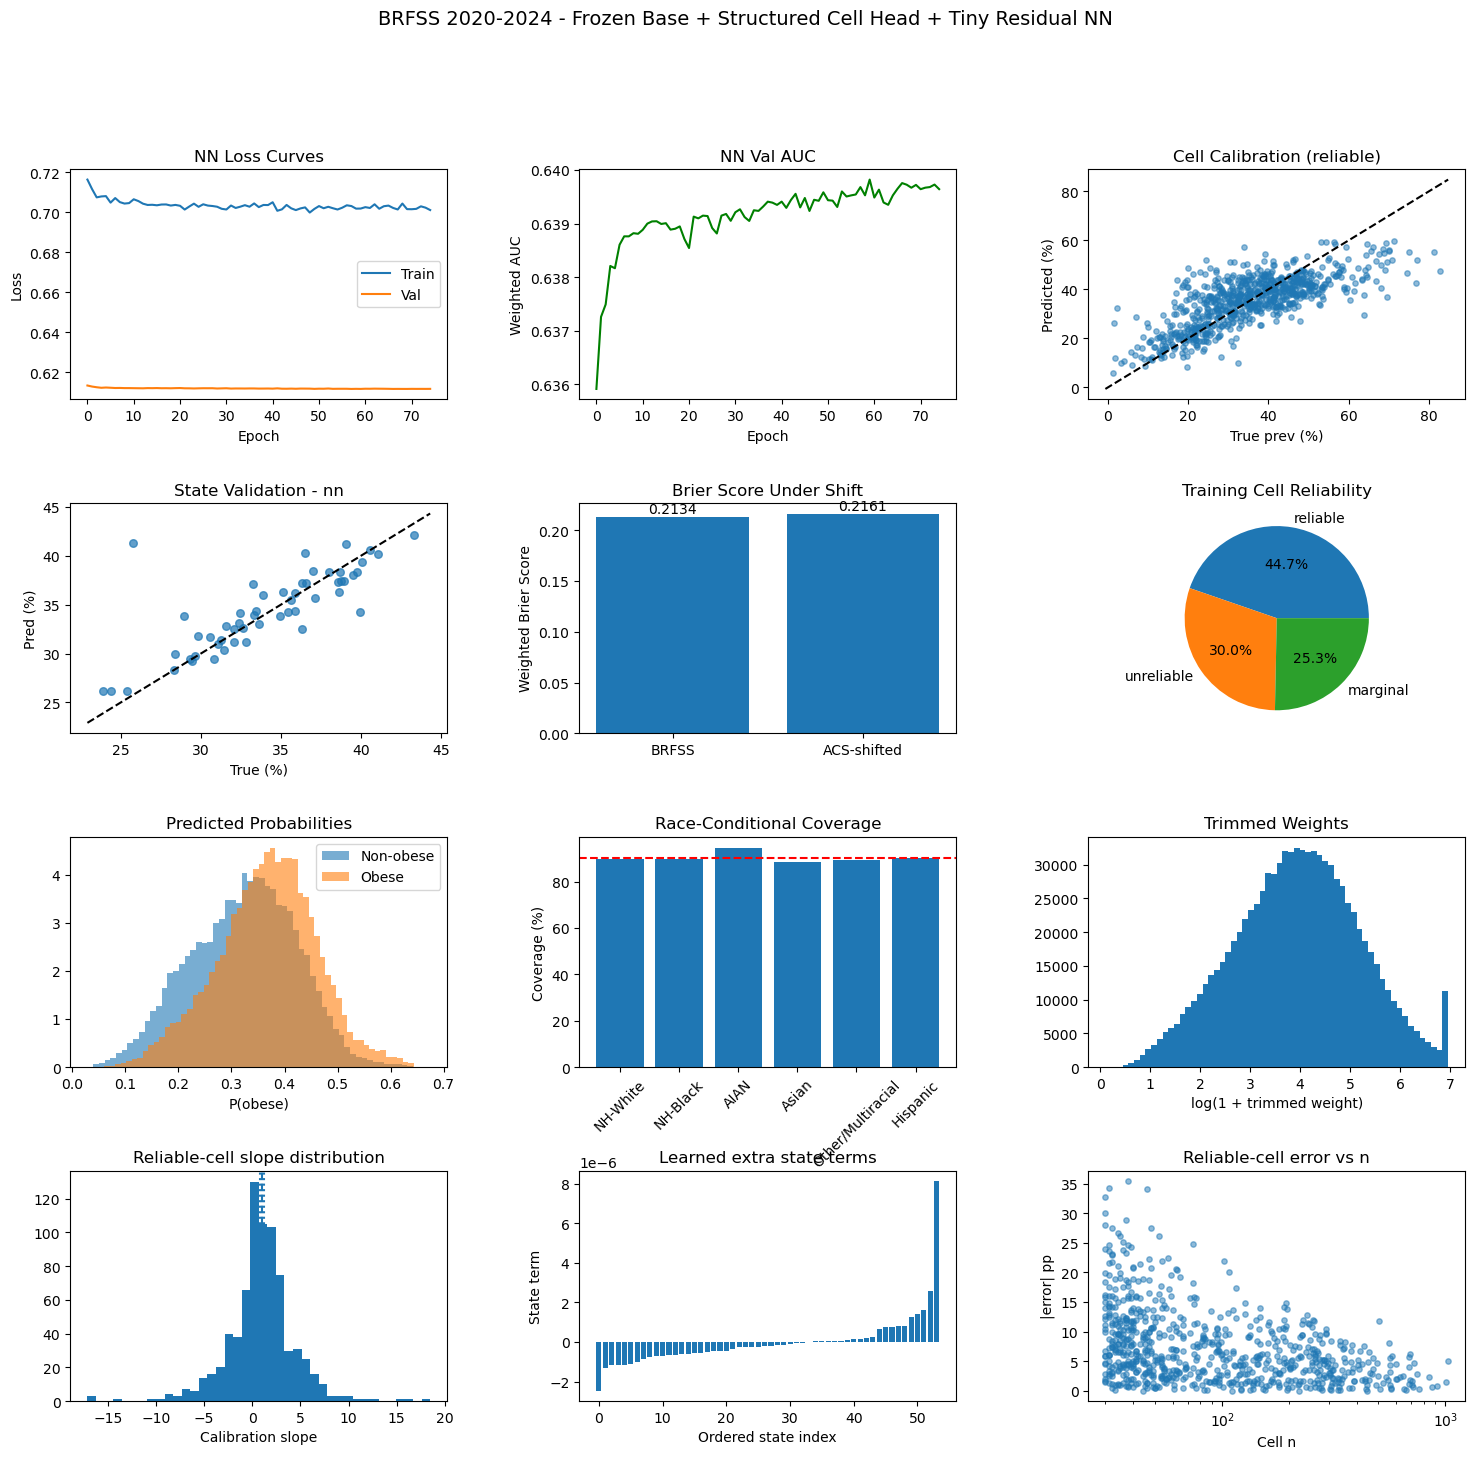

Saved: brfss_structured_frozen_base_adjusted_results.png
Saved:
  brfss_nn.pt
  brfss_encoder.pkl
  brfss_cell_reliability.csv
  brfss_race_coverage.csv
  brfss_metrics.json
  brfss_structured_frozen_base_adjusted_results.png


In [1]:
# BRFSS 2020-2024 - Frozen logistic base + structured demographic cell head + tiny residual NN
#
# Model:
#   final_logit = beta * (alpha * frozen_base_logit + state_term + structured_cell_head + tiny_residual_nn) + bias
#

# 1 - Environment
import subprocess, sys, os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

pkgs = [
    "torch", "scikit-learn", "pandas", "numpy", "matplotlib",
    "seaborn", "shap", "scipy", "statsmodels", "nbformat"
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"])
print("Done.")

# 2 - Configuration and Imports
CSV_PATH           = "brfss_clean_2020_2024.csv"
SEED               = 42
WEIGHT_TRIM_PCT    = 99
RELIABLE_N         = 30
MI_DATASETS        = 5
ALPHA_CONFORMAL    = 0.10

BASE_C             = 1.0
BASE_MAX_ITER      = 2000

HIDDEN_DIMS        = [32, 16]
DROPOUT            = 0.03
LR                 = 8e-4
WEIGHT_DECAY       = 1e-4
BATCH_SIZE         = 2048
MAX_EPOCHS         = 100
PATIENCE           = 15
NUM_WORKERS        = 4

STATE_EMB_DIM      = 2
USE_EXTRA_STATE_TERM = True

# Structured demographic head
FACTOR_SCALE             = 1.00
FACTOR_L2_LAMBDA         = 0.015
PAIRWISE_SCALE           = 0.45

# Reliable-cell targeting
CELL_MEAN_LAMBDA         = 2.0
CELL_BATCH_MINN          = 8
FULL_CELL_TARGET_LAMBDA  = 10.0
FULL_CELL_TARGET_STEPS   = 2
EARLY_STOP_CELL_WEIGHT   = 0.25

# Tiny residual NN
RESIDUAL_SCALE           = 0.008
RESIDUAL_L2_LAMBDA       = 0.30

# State regularization
STATE_L2_LAMBDA          = 0.08

# Anchor and affine logit recalibration
ALPHA_LAMBDA             = 0.03
BETA_LAMBDA              = 0.03
BIAS_LAMBDA              = 0.002

# Diagnostics
SLOPE_TRIM_Q_LOW         = 0.10
SLOPE_TRIM_Q_HIGH        = 0.90
SLOPE_GOOD_LOW           = 0.80
SLOPE_GOOD_HIGH          = 1.20

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression as SKLogistic
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


# 3 - Load and clean combined 2020-2024 file
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Raw shape: {df.shape}")

# If the pooled adjusted weight is not already present, compute it
if "_LLCPWT_adjusted" not in df.columns:
    if "year" not in df.columns:
        raise ValueError("Need either _LLCPWT_adjusted already present or a year column to compute it.")
    year_counts = df["year"].value_counts().sort_index()
    year_props = year_counts / len(df)
    df["_LLCPWT_adjusted"] = df["_LLCPWT"] * df["year"].map(year_props)
    print("Computed _LLCPWT_adjusted from _LLCPWT and year proportions.")
else:
    print("_LLCPWT_adjusted already present; using it directly.")

# Basic cleaning
if "_BMI5" in df.columns:
    df["_BMI5"] = pd.to_numeric(df["_BMI5"], errors="coerce")
if "_LLCPWT_adjusted" in df.columns:
    df["_LLCPWT_adjusted"] = pd.to_numeric(df["_LLCPWT_adjusted"], errors="coerce")

bmi_actual = df["_BMI5"] / 100.0
implausible = (bmi_actual < 10) | (bmi_actual > 80)
print(f"Implausible BMI removed: {implausible.sum():,}")
df.loc[implausible, ["_BMI5", "_BMI5CAT"]] = np.nan

# outcome
df["obese"] = np.where(
    df["_BMI5"] / 100.0 >= 30.0, 1.0,
    np.where(df["_BMI5"].isna(), np.nan, 0.0)
)

# keep rows with outcome and adjusted weight
df = df.dropna(subset=["obese", "_LLCPWT_adjusted"]).reset_index(drop=True)

print(f"Clean shape:       {df.shape}")
print(f"Obese prevalence:  {df['obese'].mean()*100:.1f}%")
print(f"Missing _INCOMG1:  {df['_INCOMG1'].isna().sum():,} ({df['_INCOMG1'].isna().mean()*100:.1f}%)")
print(f"Missing _AGEG5YR:  {df['_AGEG5YR'].isna().sum():,} ({df['_AGEG5YR'].isna().mean()*100:.1f}%)")

# Combined file uses _RACEPRV
CAT_FEATURES = ["_SEX", "_AGEG5YR", "_RACEPRV", "_EDUCAG", "_INCOMG1"]
CELL_COLS = CAT_FEATURES[:]
VALID_CODES = {
    "_SEX":     [1, 2],
    "_AGEG5YR": list(range(1, 14)),
    "_RACEPRV": [1, 2, 3, 4, 5, 6, 7],
    "_EDUCAG":  [1, 2, 3, 4],
    "_INCOMG1": list(range(1, 8)),
}
RACE_LABELS = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN", 4: "Asian",
    5: "NHOPI", 6: "Other/Multiracial", 7: "Hispanic"
}

def get_factor_arrays(df_imp):
    return {
        "sex": df_imp["_SEX"].fillna(0).astype(int).values,
        "age": df_imp["_AGEG5YR"].fillna(0).astype(int).values,
        "race": df_imp["_RACEPRV"].fillna(0).astype(int).values,
        "educ": df_imp["_EDUCAG"].fillna(0).astype(int).values,
        "income": df_imp["_INCOMG1"].fillna(0).astype(int).values,
    }

# 4 - Missing data mechanism check
print("=== Chi-square: is missingness independent of observed variables? ===")
print("p < 0.05 rejects MCAR\n")

for missing_col in ["_INCOMG1", "_AGEG5YR"]:
    flag = df[missing_col].isna().astype(int)
    for predictor in ["_SEX", "_RACEPRV", "_EDUCAG", "_STATE"]:
        obs = df[predictor].dropna()
        idx = obs.index.intersection(flag.index)
        ct = pd.crosstab(flag.loc[idx], obs.loc[idx])
        if ct.shape[1] < 2:
            continue
        chi2, p, _, _ = chi2_contingency(ct)
        sig = "*** MCAR REJECTED" if p < 0.05 else "OK"
        print(f"  {missing_col} missing X {predictor}: chi2={chi2:.1f}  p={p:.4f}  {sig}")
    print()

df["_INCOMG1_missing"] = df["_INCOMG1"].isna().astype(float)
df["_AGEG5YR_missing"] = df["_AGEG5YR"].isna().astype(float)
print("Missingness indicators added to df")

# 5 - Weight trimming
p_trim = np.percentile(df["_LLCPWT_adjusted"], WEIGHT_TRIM_PCT)
df["_LLCPWT_trimmed"] = np.clip(df["_LLCPWT_adjusted"], None, p_trim)
df["_LLCPWT_s"] = df["_LLCPWT_trimmed"] / df["_LLCPWT_trimmed"].mean()

ESS_before = df["_LLCPWT_adjusted"].sum()**2 / (df["_LLCPWT_adjusted"]**2).sum()
ESS_after  = df["_LLCPWT_trimmed"].sum()**2 / (df["_LLCPWT_trimmed"]**2).sum()
n_trimmed   = (df["_LLCPWT_adjusted"] > p_trim).sum()

print(f"Trim threshold (p{WEIGHT_TRIM_PCT}): {p_trim:,.1f}")
print(f"Records trimmed:  {n_trimmed:,} ({n_trimmed/len(df)*100:.2f}%)")
print(f"ESS before:       {ESS_before:,.0f}")
print(f"ESS after:        {ESS_after:,.0f}")

y_arr = df["obese"].values
w_arr = df["_LLCPWT_trimmed"].values
p_hat_n = np.average(y_arr, weights=w_arr)
var_wt = np.average((y_arr - p_hat_n)**2, weights=w_arr) / (w_arr.sum() - 1)
var_srs = p_hat_n * (1 - p_hat_n) / len(y_arr)
DEFF = var_wt / var_srs if var_srs > 0 else np.nan

print(f"\nNational DEFF (crude, not design-based): {DEFF:.3f}")
print(f"  sqrt(DEFF) = {np.sqrt(DEFF):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log1p(df["_LLCPWT_adjusted"]), bins=80, edgecolor="none")
axes[0].axvline(np.log1p(p_trim), color="red", linestyle="--", label=f"p{WEIGHT_TRIM_PCT}")
axes[0].set_title("Adjusted pooled weights (log scale)")
axes[0].legend()
axes[1].hist(np.log1p(df["_LLCPWT_trimmed"]), bins=80, edgecolor="none")
axes[1].set_title("Trimmed weights (log scale)")
plt.tight_layout()
plt.show()

# 6 - Train / Val / Test split
print("Stratified on _STATE x _RACEPRV jointly. Ensures every state x race combination appears in all three splits.")

df["_strat_key"] = (
    df["_STATE"].astype(int).astype(str) + "_" +
    df["_RACEPRV"].fillna(0).astype(int).astype(str)
)
key_counts = df["_strat_key"].value_counts()
df["_strat_safe"] = df["_strat_key"].where(
    df["_strat_key"].isin(key_counts[key_counts >= 3].index),
    other="rare"
)

idx = np.arange(len(df))
idx_tv, idx_test = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=df["_strat_safe"].values
)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.15/0.85, random_state=SEED,
    stratify=df["_strat_safe"].values[idx_tv]
)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val   = df.iloc[idx_val].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    prev = d["obese"].mean()*100
    print(f"  {name:5s}: {len(d):>7,} rows | obese {prev:.1f}% | states {d['_STATE'].nunique()} | race groups {d['_RACEPRV'].dropna().nunique()}")

# 7 - Multiple imputation (m=5)
imputed_trains, imputed_vals, imputed_tests = [], [], []
factor_trains, factor_vals, factor_tests = [], [], []

print(f"Fitting {MI_DATASETS} stochastic imputers on train set...")
for m in range(MI_DATASETS):
    imp = IterativeImputer(
        max_iter=10,
        random_state=SEED + m,
        sample_posterior=True,
        n_nearest_features=5
    )
    imp.fit(df_train[CAT_FEATURES])

    def apply_imp(df_split, imp=imp):
        X = pd.DataFrame(imp.transform(df_split[CAT_FEATURES].copy()), columns=CAT_FEATURES)
        for col, codes in VALID_CODES.items():
            X[col] = X[col].round().clip(min(codes), max(codes)).astype(int)
        return X

    tr_imp = apply_imp(df_train)
    va_imp = apply_imp(df_val)
    te_imp = apply_imp(df_test)

    imputed_trains.append(tr_imp)
    imputed_vals.append(va_imp)
    imputed_tests.append(te_imp)

    factor_trains.append(get_factor_arrays(tr_imp))
    factor_vals.append(get_factor_arrays(va_imp))
    factor_tests.append(get_factor_arrays(te_imp))

    print(f"  m={m+1} done")

print("\nImputation complete. _INCOMG1 distribution (m=1, train):")
print(imputed_trains[0]["_INCOMG1"].value_counts().sort_index())

# 8 - One-hot encoding
cats = [VALID_CODES[c] for c in CAT_FEATURES]
encoder = OneHotEncoder(categories=cats, sparse_output=False, handle_unknown="ignore")
encoder.fit(imputed_trains[0][CAT_FEATURES])

def encode_demo(df_imp, df_orig=None, add_miss=True):
    X = encoder.transform(df_imp[CAT_FEATURES]).astype(np.float32)
    if add_miss and df_orig is not None:
        miss = df_orig[["_INCOMG1_missing", "_AGEG5YR_missing"]].values.astype(np.float32)
        X = np.hstack([X, miss])
    return X

X_trains_demo = [encode_demo(d, df_train) for d in imputed_trains]
X_vals_demo   = [encode_demo(d, df_val)   for d in imputed_vals]
X_tests_demo  = [encode_demo(d, df_test)  for d in imputed_tests]
INPUT_DIM = X_trains_demo[0].shape[1]
print(f"Input dim: {INPUT_DIM}")

# 9 - Base logistic design (demo one-hot + state one-hot)
state_train_vals = sorted(df_train["_STATE"].fillna(0).astype(int).unique().tolist())
base_cats = [VALID_CODES[c] for c in CAT_FEATURES] + [state_train_vals]

base_encoder = OneHotEncoder(categories=base_cats, sparse_output=False, handle_unknown="ignore")
base_fit_df = imputed_trains[0][CAT_FEATURES].copy()
base_fit_df["_STATE"] = df_train["_STATE"].fillna(0).astype(int).values
base_encoder.fit(base_fit_df[CAT_FEATURES + ["_STATE"]])

def encode_base(df_imp, df_orig):
    tmp = df_imp[CAT_FEATURES].copy()
    tmp["_STATE"] = df_orig["_STATE"].fillna(0).astype(int).values
    return base_encoder.transform(tmp[CAT_FEATURES + ["_STATE"]]).astype(np.float32)

X_trains_base = [encode_base(imputed_trains[m], df_train) for m in range(MI_DATASETS)]
X_vals_base   = [encode_base(imputed_vals[m],   df_val)   for m in range(MI_DATASETS)]
X_tests_base  = [encode_base(imputed_tests[m],  df_test)  for m in range(MI_DATASETS)]

# 10 - Sparse cell audit
cell_counts = (
    imputed_trains[0].groupby(CELL_COLS).size()
    .reset_index(name="n_train")
)

def classify_cell(n):
    if n >= RELIABLE_N:
        return "reliable"
    if n >= 10:
        return "marginal"
    return "unreliable"

cell_counts["reliability"] = cell_counts["n_train"].map(classify_cell)
print("=== Training cell reliability ===")
print(cell_counts["reliability"].value_counts())
print(f"\nTotal unique cells: {len(cell_counts):,}")

fig, ax = plt.subplots(figsize=(10, 4))
for race, grp in cell_counts.groupby("_RACEPRV"):
    ax.hist(np.log1p(grp["n_train"]), bins=30, alpha=0.5,
            label=f"Race {int(race)}", density=True)
ax.axvline(np.log1p(RELIABLE_N), color="red", linestyle="--",
           label=f"Reliable threshold (n={RELIABLE_N})")
ax.set_xlabel("log(1 + n_train)")
ax.set_ylabel("Density")
ax.set_title("Cell size distribution by race")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

def make_cell_key(df_imp):
    return df_imp[CELL_COLS].astype(str).agg("|".join, axis=1)

train_cell_keys = make_cell_key(imputed_trains[0])
cell_map = {k: i for i, k in enumerate(sorted(train_cell_keys.unique()))}
cell_counts["cell_key"] = cell_counts[CELL_COLS].astype(str).agg("|".join, axis=1)
cell_counts["cell_id"] = cell_counts["cell_key"].map(cell_map).astype(int)

reliable_cell_ids = set(
    cell_counts.loc[cell_counts["reliability"] == "reliable", "cell_id"].astype(int).tolist()
)

def map_cell_ids(df_imp):
    return make_cell_key(df_imp).map(cell_map).fillna(-1).astype(int).values

cell_id_train = map_cell_ids(imputed_trains[0])
cell_id_val   = map_cell_ids(imputed_vals[0])
cell_ids_test = [map_cell_ids(imputed_tests[m]) for m in range(MI_DATASETS)]

train_cell_target_df = imputed_trains[0][CELL_COLS].copy()
train_cell_target_df["cell_id"] = cell_id_train
train_cell_target_df["y"] = df_train["obese"].values.astype(float)
train_cell_target_df["w"] = df_train["_LLCPWT_s"].values.astype(float)

train_cell_target_df = (
    train_cell_target_df.groupby("cell_id")
    .apply(lambda g: pd.Series({
        "n_train": len(g),
        "target_prev": np.average(g["y"], weights=g["w"])
    }))
    .reset_index()
)
train_cell_target_df["reliability"] = train_cell_target_df["n_train"].map(classify_cell)
train_cell_target_df = train_cell_target_df[train_cell_target_df["reliability"] == "reliable"].copy()

reliable_target_map = {
    int(r.cell_id): float(r.target_prev)
    for r in train_cell_target_df.itertuples(index=False)
}
print(f"Reliable cells with target prevalences: {len(reliable_target_map):,}")

reliable_ids_sorted = sorted(reliable_target_map.keys())
reliable_index_lookup = np.full(len(cell_map) + 1, -1, dtype=np.int64)
for pos, cid in enumerate(reliable_ids_sorted):
    reliable_index_lookup[cid + 1] = pos

reliable_index_lookup_t = torch.tensor(reliable_index_lookup, dtype=torch.long, device=DEVICE)
reliable_target_tensor = torch.tensor(
    [reliable_target_map[cid] for cid in reliable_ids_sorted],
    dtype=torch.float32,
    device=DEVICE
)

# 11 - State encoder for NN
state_le = LabelEncoder()
df_train["state_idx"] = state_le.fit_transform(df_train["_STATE"].fillna(0).astype(int))
df_val["state_idx"]   = state_le.transform(df_val["_STATE"].fillna(0).astype(int))
df_test["state_idx"]  = state_le.transform(df_test["_STATE"].fillna(0).astype(int))
NUM_STATES = len(state_le.classes_)
print(f"NUM_STATES: {NUM_STATES}")

# 12 - Frozen base logistic fits across m=5
y_train = df_train["obese"].values.astype(float)
w_train = df_train["_LLCPWT_s"].values
y_val   = df_val["obese"].values.astype(float)
w_val   = df_val["_LLCPWT_s"].values
y_test  = df_test["obese"].values.astype(float)
w_test  = df_test["_LLCPWT_s"].values

base_models = []
base_logit_trains = []
base_logit_vals = []
base_logit_tests = []

print(f"Fitting frozen logistic base on {MI_DATASETS} imputed datasets...")
for m in range(MI_DATASETS):
    glm = SKLogistic(
        penalty="l2",
        C=BASE_C,
        solver="lbfgs",
        max_iter=BASE_MAX_ITER,
        random_state=SEED
    )
    glm.fit(X_trains_base[m], y_train, sample_weight=w_train)
    base_models.append(glm)

    p_tr = glm.predict_proba(X_trains_base[m])[:, 1]
    p_va = glm.predict_proba(X_vals_base[m])[:, 1]
    p_te = glm.predict_proba(X_tests_base[m])[:, 1]

    eps = 1e-6
    base_logit_trains.append(np.log(np.clip(p_tr, eps, 1-eps) / np.clip(1-p_tr, eps, 1-eps)).astype(np.float32))
    base_logit_vals.append(np.log(np.clip(p_va, eps, 1-eps) / np.clip(1-p_va, eps, 1-eps)).astype(np.float32))
    base_logit_tests.append(np.log(np.clip(p_te, eps, 1-eps) / np.clip(1-p_te, eps, 1-eps)).astype(np.float32))

    auc_m = roc_auc_score(y_val, p_va, sample_weight=w_val)
    brier_m = brier_score_loss(y_val, p_va, sample_weight=w_val)
    print(f"  m={m+1} | val AUC={auc_m:.4f} | val Brier={brier_m:.4f}")

p_base_test = np.mean([1 / (1 + np.exp(-z)) for z in base_logit_tests], axis=0)
auc_base = roc_auc_score(y_test, p_base_test, sample_weight=w_test)
brier_base = brier_score_loss(y_test, p_base_test, sample_weight=w_test)
print("\n=== Frozen Logistic Base - Test Set Metrics ===")
print(f"  Weighted AUC:               {auc_base:.4f}")
print(f"  Weighted Brier:             {brier_base:.4f}")
print(f"  Predicted prevalence:       {np.average(p_base_test, weights=w_test)*100:.2f}%")
print(f"  True prevalence:            {np.average(y_test, weights=w_test)*100:.2f}%")

# Use m=1 covariates for NN training/validation
X_train_demo = X_trains_demo[0]
X_val_demo   = X_vals_demo[0]
base_logit_train = base_logit_trains[0]
base_logit_val   = base_logit_vals[0]
factor_train = factor_trains[0]
factor_val   = factor_vals[0]


# 13 - Model: structured demographic head + tiny residual + affine logit recalibration
class StructuredCellHead(nn.Module):
    def __init__(self, factor_scale=FACTOR_SCALE, pairwise_scale=PAIRWISE_SCALE):
        super().__init__()
        self.factor_scale = factor_scale
        self.pairwise_scale = pairwise_scale

        self.sex_emb    = nn.Embedding(3, 2, padding_idx=0)
        self.age_emb    = nn.Embedding(14, 3, padding_idx=0)
        self.race_emb   = nn.Embedding(8, 3, padding_idx=0)   # 0..7, but 0 reserved
        self.educ_emb   = nn.Embedding(5, 2, padding_idx=0)
        self.income_emb = nn.Embedding(8, 2, padding_idx=0)

        dim = 2 + 3 + 3 + 2 + 2

        self.add_linear = nn.Linear(dim, 1, bias=True)
        self.inter_net = nn.Sequential(
            nn.Linear(dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

        self.age_race = nn.Bilinear(3, 3, 1, bias=False)
        self.educ_income = nn.Bilinear(2, 2, 1, bias=False)
        self.sex_age = nn.Bilinear(2, 3, 1, bias=False)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        for emb in [self.sex_emb, self.age_emb, self.race_emb, self.educ_emb, self.income_emb]:
            nn.init.zeros_(emb.weight)
        for bil in [self.age_race, self.educ_income, self.sex_age]:
            nn.init.zeros_(bil.weight)

    def forward(self, sex_idx, age_idx, race_idx, educ_idx, income_idx):
        s = self.sex_emb(sex_idx)
        a = self.age_emb(age_idx)
        r = self.race_emb(race_idx)
        e = self.educ_emb(educ_idx)
        i = self.income_emb(income_idx)

        x = torch.cat([s, a, r, e, i], dim=1)
        add = self.add_linear(x).squeeze(-1)
        inter = torch.tanh(self.inter_net(x).squeeze(-1))
        pair = (
            self.age_race(a, r).squeeze(-1)
            + self.educ_income(e, i).squeeze(-1)
            + self.sex_age(s, a).squeeze(-1)
        )
        return self.factor_scale * (add + 0.5 * inter + self.pairwise_scale * pair)

    def l2_penalty(self):
        parts = [
            self.sex_emb.weight[1:],
            self.age_emb.weight[1:],
            self.race_emb.weight[1:],
            self.educ_emb.weight[1:],
            self.income_emb.weight[1:],
            self.add_linear.weight,
            self.age_race.weight,
            self.educ_income.weight,
            self.sex_age.weight,
        ]
        for layer in self.inter_net:
            if isinstance(layer, nn.Linear):
                parts.append(layer.weight)
        return sum(p.pow(2).mean() for p in parts)

class FrozenBaseStructuredNN(nn.Module):
    def __init__(self, input_dim, n_states, state_emb_dim=STATE_EMB_DIM,
                 hidden=None, dropout=DROPOUT, residual_scale=RESIDUAL_SCALE,
                 use_extra_state_term=USE_EXTRA_STATE_TERM):
        super().__init__()
        if hidden is None:
            hidden = HIDDEN_DIMS

        self.residual_scale = residual_scale
        self.use_extra_state_term = use_extra_state_term

        self.state_emb = nn.Embedding(n_states, state_emb_dim)
        self.state_head = nn.Linear(state_emb_dim, 1, bias=False)
        self.cell_head = StructuredCellHead()

        full_dim = input_dim + state_emb_dim + 1

        self.resid_net = nn.Sequential(
            nn.Linear(full_dim, hidden[0]),
            nn.BatchNorm1d(hidden[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[0], hidden[1]),
            nn.BatchNorm1d(hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[1], 1)
        )

        self.alpha_raw = nn.Parameter(torch.zeros(1))
        self.beta_raw = nn.Parameter(torch.zeros(1))
        self.bias = nn.Parameter(torch.zeros(1))

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        nn.init.zeros_(self.state_emb.weight)
        nn.init.zeros_(self.state_head.weight)
        nn.init.zeros_(self.resid_net[-1].weight)
        nn.init.zeros_(self.resid_net[-1].bias)

    def alpha(self):
        return 0.97 + 0.06 * torch.sigmoid(self.alpha_raw)

    def beta(self):
        return 0.90 + 0.30 * torch.sigmoid(self.beta_raw)

    def forward(self, x_demo, state_idx, base_logit, sex_idx, age_idx, race_idx, educ_idx, income_idx):
        if base_logit.ndim == 1:
            base_logit = base_logit.unsqueeze(1)

        s_emb = self.state_emb(state_idx)
        state_term = self.state_head(s_emb).squeeze(-1) if self.use_extra_state_term else torch.zeros(len(state_idx), device=state_idx.device)

        x = torch.cat([x_demo, s_emb, base_logit], dim=1)
        cell_term = self.cell_head(sex_idx, age_idx, race_idx, educ_idx, income_idx)
        resid_raw = self.resid_net(x).squeeze(-1)
        resid = self.residual_scale * torch.tanh(resid_raw)

        anchored = self.alpha() * base_logit.squeeze(-1) + state_term + cell_term + resid
        logits = self.beta() * anchored + self.bias
        return logits, state_term, cell_term, resid

    def get_components(self, x_demo, state_idx, base_logit, sex_idx, age_idx, race_idx, educ_idx, income_idx):
        logits, state_term, cell_term, resid = self.forward(
            x_demo, state_idx, base_logit, sex_idx, age_idx, race_idx, educ_idx, income_idx
        )
        structured = self.beta() * (self.alpha() * base_logit.squeeze(-1) + state_term + cell_term) + self.bias
        residual = self.beta() * resid
        return structured, residual, logits

def weighted_bce(logits, targets, weights):
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    return (loss * weights).mean()

def factor_l2_penalty(model):
    return model.cell_head.l2_penalty()

def state_l2_penalty(model):
    if not model.use_extra_state_term:
        return torch.tensor(0.0, device=DEVICE)
    return model.state_emb.weight.pow(2).mean() + model.state_head.weight.pow(2).mean()

def cell_mean_penalty(logits, targets, weights, cell_ids):
    probs = torch.sigmoid(logits)
    penalties = []
    for cid in torch.unique(cell_ids):
        cid_int = int(cid.item())
        if cid_int < 0 or cid_int not in reliable_cell_ids:
            continue
        mask = (cell_ids == cid)
        if mask.sum().item() < CELL_BATCH_MINN:
            continue
        w_cell = weights[mask]
        p_bar = (probs[mask] * w_cell).sum() / (w_cell.sum() + 1e-8)
        y_bar = (targets[mask] * w_cell).sum() / (w_cell.sum() + 1e-8)
        penalties.append((p_bar - y_bar).pow(2))
    if len(penalties) == 0:
        return torch.tensor(0.0, device=logits.device)
    return torch.stack(penalties).mean()

def make_loader(X_demo, base_logit, y, w, state_idx, cell_id,
                sex_idx, age_idx, race_idx, educ_idx, income_idx,
                shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_demo, dtype=torch.float32),
        torch.tensor(base_logit, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(w, dtype=torch.float32),
        torch.tensor(state_idx, dtype=torch.long),
        torch.tensor(cell_id, dtype=torch.long),
        torch.tensor(sex_idx, dtype=torch.long),
        torch.tensor(age_idx, dtype=torch.long),
        torch.tensor(race_idx, dtype=torch.long),
        torch.tensor(educ_idx, dtype=torch.long),
        torch.tensor(income_idx, dtype=torch.long),
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

# 14 - Full-train tensors for reliable-cell reconciliation
full_train_demo_t   = torch.tensor(X_train_demo, dtype=torch.float32, device=DEVICE)
full_train_base_t   = torch.tensor(base_logit_train, dtype=torch.float32, device=DEVICE)
full_train_state_t  = torch.tensor(df_train["state_idx"].values, dtype=torch.long, device=DEVICE)
full_train_cell_t   = torch.tensor(cell_id_train, dtype=torch.long, device=DEVICE)
full_train_y_t      = torch.tensor(df_train["obese"].values.astype(float), dtype=torch.float32, device=DEVICE)
full_train_w_t      = torch.tensor(df_train["_LLCPWT_s"].values.astype(float), dtype=torch.float32, device=DEVICE)
full_train_sex_t    = torch.tensor(factor_train["sex"], dtype=torch.long, device=DEVICE)
full_train_age_t    = torch.tensor(factor_train["age"], dtype=torch.long, device=DEVICE)
full_train_race_t   = torch.tensor(factor_train["race"], dtype=torch.long, device=DEVICE)
full_train_educ_t   = torch.tensor(factor_train["educ"], dtype=torch.long, device=DEVICE)
full_train_income_t = torch.tensor(factor_train["income"], dtype=torch.long, device=DEVICE)

def full_reliable_cell_target_loss(model, chunk_size=32768):
    num = torch.zeros(len(reliable_target_tensor), device=DEVICE)
    den = torch.zeros(len(reliable_target_tensor), device=DEVICE)

    n = len(full_train_y_t)
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        Xb = full_train_demo_t[start:end]
        Zb = full_train_base_t[start:end]
        Sb = full_train_state_t[start:end]
        Cb = full_train_cell_t[start:end]
        Sexb = full_train_sex_t[start:end]
        Ageb = full_train_age_t[start:end]
        Raceb = full_train_race_t[start:end]
        Educb = full_train_educ_t[start:end]
        Incomeb = full_train_income_t[start:end]
        Wb = full_train_w_t[start:end]

        valid = Cb >= 0
        if valid.sum().item() == 0:
            continue

        logits, _, _, _ = model(
            Xb[valid], Sb[valid], Zb[valid],
            Sexb[valid], Ageb[valid], Raceb[valid], Educb[valid], Incomeb[valid]
        )
        probs = torch.sigmoid(logits)

        idx = reliable_index_lookup_t[Cb[valid] + 1]
        valid2 = idx >= 0
        if valid2.sum().item() == 0:
            continue

        idx_v = idx[valid2]
        probs_v = probs[valid2]
        W_v = Wb[valid][valid2]

        num = num.index_add(0, idx_v, probs_v * W_v)
        den = den.index_add(0, idx_v, W_v)

    pred_prev = num / (den + 1e-8)
    return (pred_prev - reliable_target_tensor).pow(2).mean()

def run_full_reliable_cell_target_step(model, optimizer):
    optimizer.zero_grad()
    cell_target_loss = full_reliable_cell_target_loss(model)
    loss = FULL_CELL_TARGET_LAMBDA * cell_target_loss
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item(), cell_target_loss.item()

@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval()
    all_logits, all_y, all_w, all_c = [], [], [], []
    for X_b, z_b, y_b, w_b, s_b, c_b, sex_b, age_b, race_b, educ_b, income_b in loader:
        logits, _, _, _ = model(
            X_b.to(DEVICE),
            s_b.to(DEVICE),
            z_b.to(DEVICE),
            sex_b.to(DEVICE),
            age_b.to(DEVICE),
            race_b.to(DEVICE),
            educ_b.to(DEVICE),
            income_b.to(DEVICE),
        )
        all_logits.append(logits.cpu())
        all_y.append(y_b)
        all_w.append(w_b)
        all_c.append(c_b)
    logits = torch.cat(all_logits)
    y = torch.cat(all_y)
    w = torch.cat(all_w)
    c = torch.cat(all_c)
    probs = torch.sigmoid(logits).numpy()
    loss = weighted_bce(logits.to(DEVICE), y.to(DEVICE), w.to(DEVICE)).item()
    return probs, logits.numpy(), y.numpy(), w.numpy(), c.numpy(), loss

# 15 - Train
model_nn = FrozenBaseStructuredNN(
    input_dim=INPUT_DIM,
    n_states=NUM_STATES,
    state_emb_dim=STATE_EMB_DIM,
    residual_scale=RESIDUAL_SCALE,
    use_extra_state_term=USE_EXTRA_STATE_TERM,
).to(DEVICE)

print(model_nn)
print(f"nn parameters: {sum(p.numel() for p in model_nn.parameters() if p.requires_grad):,}")

print("=== Epoch 1 gradient norm check ===")
tmp_m = FrozenBaseStructuredNN(
    input_dim=INPUT_DIM,
    n_states=NUM_STATES,
    state_emb_dim=STATE_EMB_DIM,
    residual_scale=RESIDUAL_SCALE,
    use_extra_state_term=USE_EXTRA_STATE_TERM,
).to(DEVICE)
tmp_opt = optim.AdamW(tmp_m.parameters(), lr=LR)
tmp_ldr = make_loader(
    X_train_demo, base_logit_train,
    df_train["obese"].values, df_train["_LLCPWT_s"].values,
    df_train["state_idx"].values, cell_id_train,
    factor_train["sex"], factor_train["age"], factor_train["race"], factor_train["educ"], factor_train["income"],
    shuffle=True
)

grad_norms = []
for i, (X_b, z_b, y_b, w_b, s_b, c_b, sex_b, age_b, race_b, educ_b, income_b) in enumerate(tmp_ldr):
    if i >= 20:
        break
    tmp_opt.zero_grad()
    logits, state_term, cell_term, resid = tmp_m(
        X_b.to(DEVICE), s_b.to(DEVICE), z_b.to(DEVICE),
        sex_b.to(DEVICE), age_b.to(DEVICE), race_b.to(DEVICE), educ_b.to(DEVICE), income_b.to(DEVICE)
    )
    loss = (
        weighted_bce(logits, y_b.to(DEVICE), w_b.to(DEVICE))
        + CELL_MEAN_LAMBDA * cell_mean_penalty(logits, y_b.to(DEVICE), w_b.to(DEVICE), c_b.to(DEVICE))
        + FACTOR_L2_LAMBDA * factor_l2_penalty(tmp_m)
        + STATE_L2_LAMBDA * state_l2_penalty(tmp_m)
        + RESIDUAL_L2_LAMBDA * resid.pow(2).mean()
        + ALPHA_LAMBDA * (tmp_m.alpha() - 1.0).pow(2).mean()
        + BETA_LAMBDA * (tmp_m.beta() - 1.0).pow(2).mean()
        + BIAS_LAMBDA * tmp_m.bias.pow(2).mean()
    )
    loss.backward()
    gn = nn.utils.clip_grad_norm_(tmp_m.parameters(), float("inf"))
    grad_norms.append(gn.item())
    tmp_opt.zero_grad()

del tmp_m, tmp_opt
max_gn = max(grad_norms)
USE_WARMUP = max_gn > 10
print(f"  Max gradient norm (first 20 batches): {max_gn:.3f}")
print(f"  Warm-up needed: {USE_WARMUP} (threshold: 10)")

train_loader = make_loader(
    X_train_demo, base_logit_train,
    df_train["obese"].values, df_train["_LLCPWT_s"].values,
    df_train["state_idx"].values, cell_id_train,
    factor_train["sex"], factor_train["age"], factor_train["race"], factor_train["educ"], factor_train["income"],
    shuffle=True
)
val_loader = make_loader(
    X_val_demo, base_logit_val,
    df_val["obese"].values, df_val["_LLCPWT_s"].values,
    df_val["state_idx"].values, cell_id_val,
    factor_val["sex"], factor_val["age"], factor_val["race"], factor_val["educ"], factor_val["income"],
    shuffle=False
)

optimizer = optim.AdamW(model_nn.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

if USE_WARMUP:
    WARMUP = 5
    def lr_lambda(ep):
        return (ep + 1) / WARMUP if ep < WARMUP else \
               0.5 * (1 + np.cos(np.pi * (ep - WARMUP) / (MAX_EPOCHS - WARMUP)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
else:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_auc": []}
best_score, best_state, no_improve = np.inf, None, 0

print(f"{'Epoch':>5} {'Train':>10} {'Val':>10} {'AUC':>8} {'LR':>10}")
print("-" * 50)

for epoch in range(1, MAX_EPOCHS + 1):
    model_nn.train()
    total_loss, total_n = 0.0, 0

    for X_b, z_b, y_b, w_b, s_b, c_b, sex_b, age_b, race_b, educ_b, income_b in train_loader:
        X_b = X_b.to(DEVICE)
        z_b = z_b.to(DEVICE)
        y_b = y_b.to(DEVICE)
        w_b = w_b.to(DEVICE)
        s_b = s_b.to(DEVICE)
        c_b = c_b.to(DEVICE)
        sex_b = sex_b.to(DEVICE)
        age_b = age_b.to(DEVICE)
        race_b = race_b.to(DEVICE)
        educ_b = educ_b.to(DEVICE)
        income_b = income_b.to(DEVICE)

        optimizer.zero_grad()
        logits, state_term, cell_term, resid = model_nn(
            X_b, s_b, z_b, sex_b, age_b, race_b, educ_b, income_b
        )

        bce = weighted_bce(logits, y_b, w_b)
        cell_pen = cell_mean_penalty(logits, y_b, w_b, c_b)
        factor_pen = factor_l2_penalty(model_nn)
        state_pen = state_l2_penalty(model_nn)
        resid_l2 = resid.pow(2).mean()
        alpha_pen = (model_nn.alpha() - 1.0).pow(2).mean()
        beta_pen = (model_nn.beta() - 1.0).pow(2).mean()
        bias_pen = model_nn.bias.pow(2).mean()

        loss = (
            bce
            + CELL_MEAN_LAMBDA * cell_pen
            + FACTOR_L2_LAMBDA * factor_pen
            + STATE_L2_LAMBDA * state_pen
            + RESIDUAL_L2_LAMBDA * resid_l2
            + ALPHA_LAMBDA * alpha_pen
            + BETA_LAMBDA * beta_pen
            + BIAS_LAMBDA * bias_pen
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_b)
        total_n += len(y_b)

    tr_loss = total_loss / total_n

    recon_total = 0.0
    recon_core = 0.0
    for _ in range(FULL_CELL_TARGET_STEPS):
        rt, rc = run_full_reliable_cell_target_step(model_nn, optimizer)
        recon_total += rt
        recon_core += rc
    recon_total /= FULL_CELL_TARGET_STEPS
    recon_core /= FULL_CELL_TARGET_STEPS

    probs_v, logits_v, y_v, w_v, c_v, val_loss = evaluate_loader(model_nn, val_loader)
    val_auc = roc_auc_score(y_v, probs_v, sample_weight=w_v)
    val_cell_pen = cell_mean_penalty(
        torch.tensor(logits_v, dtype=torch.float32, device=DEVICE),
        torch.tensor(y_v, dtype=torch.float32, device=DEVICE),
        torch.tensor(w_v, dtype=torch.float32, device=DEVICE),
        torch.tensor(c_v, dtype=torch.long, device=DEVICE),
    ).item()
    val_score = val_loss + EARLY_STOP_CELL_WEIGHT * val_cell_pen

    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>5} {tr_loss:>10.5f} {val_loss:>10.5f} {val_auc:>8.4f} {lr_now:>10.2e} | cell={val_cell_pen:.5f}")

    if val_score < best_score - 1e-5:
        best_score = val_score
        best_state = {k: v.cpu().clone() for k, v in model_nn.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch} | best val score {best_score:.5f}")
            break

model_nn.load_state_dict(best_state)
print(f"\nBest weights restored | val score: {best_score:.5f}")

probs_tr, logits_tr, y_tr, w_tr, c_tr, _ = evaluate_loader(
    model_nn,
    make_loader(
        X_train_demo, base_logit_train,
        df_train["obese"].values, df_train["_LLCPWT_s"].values,
        df_train["state_idx"].values, cell_id_train,
        factor_train["sex"], factor_train["age"], factor_train["race"], factor_train["educ"], factor_train["income"],
        shuffle=False
    )
)
loss_w = brier_score_loss(y_tr, probs_tr, sample_weight=w_tr)
loss_uw = brier_score_loss(y_tr, probs_tr)
print(f"Weighted Brier (train):   {loss_w:.4f}")
print(f"Unweighted Brier (train): {loss_uw:.4f}")
if abs(loss_w - loss_uw) > 0.05:
    print("WARNING: Large divergence - consider reducing trim to p95")

@torch.no_grad()
def summarize_state_term(model):
    if not model.use_extra_state_term:
        print("\n=== Extra State Term Diagnostic ===")
        print("  USE_EXTRA_STATE_TERM = False")
        return None
    u = torch.arange(model.state_emb.num_embeddings, device=DEVICE, dtype=torch.long)
    s_emb = model.state_emb(u)
    st = model.state_head(s_emb).squeeze(-1).cpu().numpy()
    print("\n=== Extra State Term Diagnostic ===")
    print(f"  mean abs state term: {np.mean(np.abs(st)):.4f}")
    print(f"  max abs state term:  {np.max(np.abs(st)):.4f}")
    print(f"  sd state term:       {np.std(st):.4f}")
    return st

state_term_values = summarize_state_term(model_nn)

# 16 - Nonlinearity diagnostic
model_nn.eval()
N_DIAG = min(5000, len(df_test))
X_samp = torch.tensor(X_tests_demo[0][:N_DIAG], dtype=torch.float32, device=DEVICE)
s_samp = torch.tensor(df_test["state_idx"].values[:N_DIAG], dtype=torch.long, device=DEVICE)
z_samp = torch.tensor(base_logit_tests[0][:N_DIAG], dtype=torch.float32, device=DEVICE)
sex_samp = torch.tensor(factor_tests[0]["sex"][:N_DIAG], dtype=torch.long, device=DEVICE)
age_samp = torch.tensor(factor_tests[0]["age"][:N_DIAG], dtype=torch.long, device=DEVICE)
race_samp = torch.tensor(factor_tests[0]["race"][:N_DIAG], dtype=torch.long, device=DEVICE)
educ_samp = torch.tensor(factor_tests[0]["educ"][:N_DIAG], dtype=torch.long, device=DEVICE)
income_samp = torch.tensor(factor_tests[0]["income"][:N_DIAG], dtype=torch.long, device=DEVICE)

with torch.no_grad():
    base_part, resid_part, total = model_nn.get_components(
        X_samp, s_samp, z_samp, sex_samp, age_samp, race_samp, educ_samp, income_samp
    )
    structured = base_part.cpu()
    resid_part = resid_part.cpu()
    total = total.cpu()

structured_c = structured - structured.mean()
resid_c = resid_part - resid_part.mean()
proj = torch.dot(resid_c.flatten(), structured_c.flatten()) / (torch.dot(structured_c.flatten(), structured_c.flatten()) + 1e-8)
resid_orth = resid_c - proj * structured_c
var_struct = structured_c.var().item()
var_resid = resid_orth.var().item()
var_total = (total - total.mean()).var().item()
cov_share = 1.0 - (var_struct + var_resid) / (var_total + 1e-8)

print("=== Variance Decomposition of Logit Predictions ===")
print(f"  Structured baseline share:     {var_struct/var_total:.3f}")
print(f"  Orthogonal residual share:     {var_resid/var_total:.3f}")
print(f"  Cross-term (covariance) share: {cov_share:.3f}")
resid_pct = var_resid / var_total * 100
if resid_pct < 5:
    print(f"\n  {resid_pct:.1f}% residual -> structure dominates")
elif resid_pct < 20:
    print(f"\n  {resid_pct:.1f}% residual -> small NN component justified")
else:
    print(f"\n  {resid_pct:.1f}% residual -> NN clearly doing a lot")

# 17 - Test evaluation across imputations
y_test_arr = df_test["obese"].values.astype(float)
w_test_arr = df_test["_LLCPWT_s"].values

p_nn_per_m = []
for m_idx in range(MI_DATASETS):
    Xm_demo_t = torch.tensor(X_tests_demo[m_idx], dtype=torch.float32, device=DEVICE)
    Zm_t = torch.tensor(base_logit_tests[m_idx], dtype=torch.float32, device=DEVICE)
    Sm_t = torch.tensor(df_test["state_idx"].values, dtype=torch.long, device=DEVICE)
    sex_tm = torch.tensor(factor_tests[m_idx]["sex"], dtype=torch.long, device=DEVICE)
    age_tm = torch.tensor(factor_tests[m_idx]["age"], dtype=torch.long, device=DEVICE)
    race_tm = torch.tensor(factor_tests[m_idx]["race"], dtype=torch.long, device=DEVICE)
    educ_tm = torch.tensor(factor_tests[m_idx]["educ"], dtype=torch.long, device=DEVICE)
    income_tm = torch.tensor(factor_tests[m_idx]["income"], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits_m, _, _, _ = model_nn(Xm_demo_t, Sm_t, Zm_t, sex_tm, age_tm, race_tm, educ_tm, income_tm)
        logits_m = logits_m.cpu().numpy()
    p_nn_per_m.append(1.0 / (1.0 + np.exp(-logits_m)))

p_nn_test = np.mean(p_nn_per_m, axis=0)
p_mi_std = np.std(p_nn_per_m, axis=0)
auc_nn = roc_auc_score(y_test_arr, p_nn_test, sample_weight=w_test_arr)
brier_nn = brier_score_loss(y_test_arr, p_nn_test, sample_weight=w_test_arr)
prev_pred_f = np.average(p_nn_test, weights=w_test_arr) * 100
prev_true = np.average(y_test_arr, weights=w_test_arr) * 100

print("=== nn - Test Set Metrics ===")
print(f"  Weighted AUC:               {auc_nn:.4f}")
print(f"  Weighted Brier:             {brier_nn:.4f}")
print(f"  Predicted prevalence:       {prev_pred_f:.2f}%")
print(f"  True prevalence:            {prev_true:.2f}%")
print(f"  Prevalence gap:             {abs(prev_pred_f - prev_true):.2f}pp")
print(f"  Mean between-imputation SD: {p_mi_std.mean():.4f}")

# 18 - Cell calibration
def cell_calibration(p_hat, y, w, df_split, df_imp, label="Model"):
    cdf = df_imp[CELL_COLS].copy()
    cdf["p_hat"] = p_hat
    cdf["y"] = y
    cdf["w"] = w
    records = []

    for cell, grp in cdf.groupby(CELL_COLS):
        n = len(grp)
        pred_prev = np.average(grp["p_hat"], weights=grp["w"])
        true_prev = np.average(grp["y"], weights=grp["w"])
        slope = np.nan
        if n >= RELIABLE_N and grp["y"].nunique() > 1:
            lp = np.log(grp["p_hat"].clip(1e-6, 1-1e-6) / (1 - grp["p_hat"].clip(1e-6, 1-1e-6)))
            try:
                cm = SKLogistic(
                    penalty="l2",
                    C=1e6,
                    solver="lbfgs",
                    max_iter=200
                ).fit(
                    lp.values.reshape(-1, 1),
                    grp["y"].values,
                    sample_weight=grp["w"].values
                )
                slope = cm.coef_[0][0]
            except Exception:
                pass
        records.append({
            "cell": cell,
            "n": n,
            "pred_prev": pred_prev,
            "true_prev": true_prev,
            "error": pred_prev - true_prev,
            "cal_slope": slope,
            "reliability": classify_cell(n)
        })

    result = pd.DataFrame(records)
    rel = result[result["reliability"] == "reliable"]
    marg = result[result["reliability"] == "marginal"]

    print(f"\n=== {label} - Cell Calibration ===")
    print(f"  Reliable cells (n>={RELIABLE_N}): {len(rel):,}")
    if len(rel):
        print(f"    Mean |error|:   {rel['error'].abs().mean()*100:.2f}pp")
        slopes = rel["cal_slope"].dropna()
        if len(slopes):
            trimmed = slopes[(slopes >= slopes.quantile(SLOPE_TRIM_Q_LOW)) & (slopes <= slopes.quantile(SLOPE_TRIM_Q_HIGH))]
            frac_good = ((slopes >= SLOPE_GOOD_LOW) & (slopes <= SLOPE_GOOD_HIGH)).mean()
            print(f"    Slopes: mean={slopes.mean():.3f} std={slopes.std():.3f} median={slopes.median():.3f}")
            print(f"    Trimmed mean ({SLOPE_TRIM_Q_LOW:.0%}-{SLOPE_TRIM_Q_HIGH:.0%}): {trimmed.mean():.3f}")
            print(f"    Fraction in [{SLOPE_GOOD_LOW:.1f}, {SLOPE_GOOD_HIGH:.1f}]: {frac_good:.3f}")
            if slopes.mean() < 0.85:
                print("    WARNING: overconfident / too spread")
            if slopes.mean() > 1.15:
                print("    WARNING: underconfident / too flat")
    print(f"  Marginal cells (10-{RELIABLE_N}): {len(marg):,}")
    if len(marg):
        print(f"    Mean |error|: {marg['error'].abs().mean()*100:.2f}pp")
    return result

cell_cal_nn = cell_calibration(p_nn_test, y_test_arr, w_test_arr, df_test, imputed_tests[0], "nn")


# 19 - State-level validation
def state_validation(p_hat, y, w, states, label="Model"):
    df_s = pd.DataFrame({"p": p_hat, "y": y, "w": w, "state": states})
    grp = df_s.groupby("state").apply(lambda g: pd.Series({
        "pred": np.average(g["p"], weights=g["w"]) * 100,
        "true": np.average(g["y"], weights=g["w"]) * 100,
        "n": len(g)
    })).reset_index()
    grp["residual"] = grp["pred"] - grp["true"]
    corr = grp[["pred", "true"]].corr().iloc[0, 1]
    mae = grp["residual"].abs().mean()
    print(f"\n=== {label} - State Validation ===")
    print(f"  Pred vs True corr:   {corr:.4f}")
    print(f"  Mean |error|:        {mae:.2f}pp")
    print(f"  Max |error|:         {grp['residual'].abs().max():.2f}pp")
    print(f"  States |err|>3pp:    {(grp['residual'].abs()>3).sum()}")
    return grp

state_nn = state_validation(p_nn_test, y_test_arr, w_test_arr, df_test["_STATE"].values, "nn")

# 20 - Subgroup AUC by Race
def subgroup_auc(p_hat, y, w, df_imp, label="Model"):
    race_col = df_imp["_RACEPRV"].values
    print(f"\n=== {label} - Subgroup AUC by Race ===")
    for code, name in RACE_LABELS.items():
        mask = race_col == code
        n = mask.sum()
        if n < 50:
            print(f"  {name:20s} n={n:>6}  SKIPPED (n<50 - sparse)")
            continue
        if y[mask].max() == y[mask].min():
            print(f"  {name:20s} n={n:>6}  ERROR (single class)")
            continue
        sub_auc = roc_auc_score(y[mask], p_hat[mask], sample_weight=w[mask])
        flag = " WARNING AUC<0.55" if sub_auc < 0.55 else ""
        print(f"  {name:20s} n={n:>6,}  AUC={sub_auc:.4f}{flag}")

subgroup_auc(p_nn_test, y_test_arr, w_test_arr, imputed_tests[0], "nn")

# 21 - ACS shift test
ACS_MARGINALS = {
    "_SEX":    {1: 0.487, 2: 0.513},
    "_EDUCAG": {1: 0.088, 2: 0.270, 3: 0.290, 4: 0.352},
    "_RACEPRV": {1: 0.596, 2: 0.121, 3: 0.009, 4: 0.060, 5: 0.002, 6: 0.079, 7: 0.133},
}

def compute_shift_weights(df_imp):
    rng = np.random.RandomState(SEED)
    n = len(df_imp)
    acs_sim = {}
    for col, dist in ACS_MARGINALS.items():
        codes = list(dist.keys())
        probs = np.array(list(dist.values()))
        probs /= probs.sum()
        acs_sim[col] = rng.choice(codes, size=n, p=probs)
    df_acs = pd.DataFrame(acs_sim)
    brfss_enc = pd.get_dummies(df_imp[list(ACS_MARGINALS.keys())]).astype(float)
    acs_enc = pd.get_dummies(df_acs).reindex(columns=brfss_enc.columns, fill_value=0)
    X_comb = np.vstack([brfss_enc.values, acs_enc.values])
    y_comb = np.concatenate([np.zeros(n), np.ones(n)])
    clf = SKLogistic(max_iter=500, C=1.0).fit(X_comb, y_comb)
    log_odds = clf.predict_log_proba(brfss_enc.values)
    sw = np.exp(log_odds[:, 1] - log_odds[:, 0])
    return sw / sw.mean()

shift_w = compute_shift_weights(imputed_tests[0])

print("=== ACS Distribution Shift Test ===")
w_comb = w_test_arr * shift_w
w_comb /= w_comb.mean()
brier_brfss_nn = brier_score_loss(y_test_arr, p_nn_test, sample_weight=w_test_arr)
brier_acs_nn = brier_score_loss(y_test_arr, p_nn_test, sample_weight=w_comb)
gap = abs(brier_acs_nn - brier_brfss_nn)
flag = " WARNING: large shift gap" if gap > 0.01 else " OK"
print(f"  nn: Brier(BRFSS)={brier_brfss_nn:.4f}  Brier(ACS-shifted)={brier_acs_nn:.4f}  gap={gap:.4f}{flag}")

# 22 - Race-conditional conformal prediction
X_val_t_demo = torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE)
Z_val_t = torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE)
S_val_t = torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE)
sex_val_t = torch.tensor(factor_val["sex"], dtype=torch.long, device=DEVICE)
age_val_t = torch.tensor(factor_val["age"], dtype=torch.long, device=DEVICE)
race_val_t = torch.tensor(factor_val["race"], dtype=torch.long, device=DEVICE)
educ_val_t = torch.tensor(factor_val["educ"], dtype=torch.long, device=DEVICE)
income_val_t = torch.tensor(factor_val["income"], dtype=torch.long, device=DEVICE)

with torch.no_grad():
    logits_val_final, _, _, _ = model_nn(
        X_val_t_demo,
        S_val_t,
        Z_val_t,
        sex_val_t,
        age_val_t,
        race_val_t,
        educ_val_t,
        income_val_t,
    )
p_val = torch.sigmoid(logits_val_final).cpu().numpy()

y_val_np = df_val["obese"].values.astype(float)
race_val = imputed_vals[0]["_RACEPRV"].values.astype(int)

q_hat_global = np.quantile(
    np.abs(y_val_np - p_val),
    np.ceil((len(y_val_np) + 1) * (1 - ALPHA_CONFORMAL)) / len(y_val_np)
)

q_hat_by_race = {}
print(f'{"Race":20s} {"n":>7} {"q_hat":>8} {"Note"}')
for rc in range(1, 8):
    mask = race_val == rc
    n_r = mask.sum()
    if n_r < 100:
        q_hat_by_race[rc] = q_hat_global
        print(f"{RACE_LABELS[rc]:20s} {n_r:>7} {q_hat_global:>8.4f}  fallback to global")
        continue
    scores = np.abs(y_val_np[mask] - p_val[mask])
    q_r = np.quantile(scores, np.ceil((n_r + 1) * (1 - ALPHA_CONFORMAL)) / n_r)
    q_hat_by_race[rc] = q_r
    print(f"{RACE_LABELS[rc]:20s} {n_r:>7} {q_r:>8.4f}")

race_test = imputed_tests[0]["_RACEPRV"].values.astype(int)
cell_n_test = (
    imputed_tests[0]
    .merge(cell_counts[CELL_COLS + ["n_train"]], on=CELL_COLS, how="left")["n_train"]
    .fillna(0).values
)

lo_arr, hi_arr, flag_arr = [], [], []
for p, rc, n_tr in zip(p_nn_test, race_test, cell_n_test):
    q = q_hat_by_race.get(int(rc), q_hat_global)
    if n_tr < 10:
        lo_arr.append(np.nan)
        hi_arr.append(np.nan)
        flag_arr.append("unreliable")
    else:
        lo_arr.append(np.clip(p - q, 0, 1))
        hi_arr.append(np.clip(p + q, 0, 1))
        flag_arr.append("marginal" if n_tr < RELIABLE_N else "reliable")

lo_test, hi_test, flag_test = np.array(lo_arr), np.array(hi_arr), np.array(flag_arr)

race_cov_rows = []
print(f"\n=== Race-Conditional Coverage (target >= {(1-ALPHA_CONFORMAL)*100:.0f}%) ===")
for rc, name in RACE_LABELS.items():
    mask = (race_test == rc) & (flag_test == "reliable")
    if mask.sum() < 50:
        continue
    covered = ((y_test_arr[mask] >= lo_test[mask]) & (y_test_arr[mask] <= hi_test[mask])).mean()
    ok = "OK" if covered >= (1 - ALPHA_CONFORMAL) else "BELOW TARGET"
    race_cov_rows.append({"race": name, "coverage": covered, "n": int(mask.sum())})
    print(f"  {name:20s}: {covered*100:.1f}%  n={mask.sum():,}  {ok}")

race_cov_df = pd.DataFrame(race_cov_rows)

# 23 - Permutation importance
try:
    print("Computing permutation-style feature importance...")
    base_auc_val = roc_auc_score(y_val_np, p_val, sample_weight=df_val["_LLCPWT_s"].values)

    rng_perm = np.random.RandomState(SEED)
    perm_rows = []

    Xp_demo = X_val_demo.copy()
    perm = rng_perm.permutation(len(Xp_demo))
    Xp_demo = Xp_demo[perm]
    with torch.no_grad():
        lp, _, _, _ = model_nn(
            torch.tensor(Xp_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE),
            torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE),
            torch.tensor(factor_val["sex"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["age"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["race"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["educ"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["income"], dtype=torch.long, device=DEVICE),
        )
    p_perm = torch.sigmoid(lp).cpu().numpy()
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "demo_onehot", "delta_auc": base_auc_val - auc_perm})

    state_perm = rng_perm.permutation(df_val["state_idx"].values)
    with torch.no_grad():
        lp, _, _, _ = model_nn(
            torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(state_perm, dtype=torch.long, device=DEVICE),
            torch.tensor(base_logit_val, dtype=torch.float32, device=DEVICE),
            torch.tensor(factor_val["sex"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["age"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["race"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["educ"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["income"], dtype=torch.long, device=DEVICE),
        )
    p_perm = torch.sigmoid(lp).cpu().numpy()
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "state_idx", "delta_auc": base_auc_val - auc_perm})

    z_perm = rng_perm.permutation(base_logit_val)
    with torch.no_grad():
        lp, _, _, _ = model_nn(
            torch.tensor(X_val_demo, dtype=torch.float32, device=DEVICE),
            torch.tensor(df_val["state_idx"].values, dtype=torch.long, device=DEVICE),
            torch.tensor(z_perm, dtype=torch.float32, device=DEVICE),
            torch.tensor(factor_val["sex"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["age"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["race"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["educ"], dtype=torch.long, device=DEVICE),
            torch.tensor(factor_val["income"], dtype=torch.long, device=DEVICE),
        )
    p_perm = torch.sigmoid(lp).cpu().numpy()
    auc_perm = roc_auc_score(y_val_np, p_perm, sample_weight=df_val["_LLCPWT_s"].values)
    perm_rows.append({"feature": "base_logit", "delta_auc": base_auc_val - auc_perm})

    perm_df = pd.DataFrame(perm_rows).sort_values("delta_auc", ascending=False)
    print("\n=== Permutation Importance (validation AUC drop) ===")
    print(perm_df.to_string(index=False))

except Exception as e:
    print(f"Permutation importance failed: {e}")
    perm_df = pd.DataFrame()

# 24 - Final model snapshot
print("=== FINAL NN MODEL SNAPSHOT ===")
print(f"Weighted AUC:   {auc_nn:.4f}")
print(f"Weighted Brier: {brier_nn:.4f}")
reliable_cells = cell_cal_nn[cell_cal_nn["reliability"] == "reliable"]
marginal_cells = cell_cal_nn[cell_cal_nn["reliability"] == "marginal"]
print(f"Reliable-cell mean |error|: {reliable_cells['error'].abs().mean()*100:.2f}pp")
print(f"Marginal-cell mean |error|:  {marginal_cells['error'].abs().mean()*100:.2f}pp")
if reliable_cells["cal_slope"].notna().any():
    slopes = reliable_cells['cal_slope'].dropna()
    print(f"Reliable-cell calibration slope mean:   {slopes.mean():.3f}")
    print(f"Reliable-cell calibration slope median: {slopes.median():.3f}")

# 25 - Summary plots
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("BRFSS 2020-2024 - Frozen Base + Structured Cell Head + Tiny Residual NN", fontsize=14)

ax = fig.add_subplot(gs[0, 0])
ax.plot(history["train_loss"], label="Train")
ax.plot(history["val_loss"], label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("NN Loss Curves")
ax.legend()

ax = fig.add_subplot(gs[0, 1])
ax.plot(history["val_auc"], color="green")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted AUC")
ax.set_title("NN Val AUC")

ax = fig.add_subplot(gs[0, 2])
rel = cell_cal_nn[cell_cal_nn["reliability"] == "reliable"]
if len(rel):
    ax.scatter(rel["true_prev"]*100, rel["pred_prev"]*100, s=15, alpha=0.5)
    mn = min(rel["true_prev"].min(), rel["pred_prev"].min())*100 - 2
    mx = max(rel["true_prev"].max(), rel["pred_prev"].max())*100 + 2
    ax.plot([mn, mx], [mn, mx], "k--")
ax.set_xlabel("True prev (%)")
ax.set_ylabel("Predicted (%)")
ax.set_title("Cell Calibration (reliable)")

ax = fig.add_subplot(gs[1, 0])
ax.scatter(state_nn["true"], state_nn["pred"], s=30, alpha=0.7)
mn = min(state_nn[["true", "pred"]].min()) - 1
mx = max(state_nn[["true", "pred"]].max()) + 1
ax.plot([mn, mx], [mn, mx], "k--")
ax.set_xlabel("True (%)")
ax.set_ylabel("Pred (%)")
ax.set_title("State Validation - nn")

ax = fig.add_subplot(gs[1, 1])
bars = ax.bar(["BRFSS", "ACS-shifted"], [brier_brfss_nn, brier_acs_nn])
ax.set_ylabel("Weighted Brier Score")
ax.set_title("Brier Score Under Shift")
for bar, b in zip(bars, [brier_brfss_nn, brier_acs_nn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{b:.4f}",
            ha="center", va="bottom")

ax = fig.add_subplot(gs[1, 2])
rc = cell_counts["reliability"].value_counts()
ax.pie(rc.values, labels=rc.index, autopct="%1.1f%%")
ax.set_title("Training Cell Reliability")

ax = fig.add_subplot(gs[2, 0])
ax.hist(p_nn_test[y_test_arr == 0], bins=60, alpha=0.6, label="Non-obese", density=True)
ax.hist(p_nn_test[y_test_arr == 1], bins=60, alpha=0.6, label="Obese", density=True)
ax.set_xlabel("P(obese)")
ax.set_title("Predicted Probabilities")
ax.legend()

ax = fig.add_subplot(gs[2, 1])
if len(race_cov_df):
    ax.bar(race_cov_df["race"], race_cov_df["coverage"]*100)
    ax.axhline((1-ALPHA_CONFORMAL)*100, linestyle="--", color="red")
    ax.set_ylabel("Coverage (%)")
    ax.set_title("Race-Conditional Coverage")
    ax.tick_params(axis='x', rotation=45)

ax = fig.add_subplot(gs[2, 2])
ax.hist(np.log1p(df["_LLCPWT_trimmed"]), bins=60, edgecolor="none")
ax.set_xlabel("log(1 + trimmed weight)")
ax.set_title("Trimmed Weights")

ax = fig.add_subplot(gs[3, 0])
if reliable_cells["cal_slope"].notna().any():
    slopes = reliable_cells["cal_slope"].dropna()
    ax.hist(slopes, bins=40)
    ax.axvline(1.0, linestyle='--')
    ax.axvline(SLOPE_GOOD_LOW, linestyle=':')
    ax.axvline(SLOPE_GOOD_HIGH, linestyle=':')
ax.set_title("Reliable-cell slope distribution")
ax.set_xlabel("Calibration slope")

ax = fig.add_subplot(gs[3, 1])
if state_term_values is not None:
    ax.bar(np.arange(len(state_term_values)), np.sort(state_term_values))
    ax.set_title("Learned extra state terms")
    ax.set_xlabel("Ordered state index")
    ax.set_ylabel("State term")
else:
    ax.text(0.5, 0.5, "Extra state term disabled", ha='center', va='center')
    ax.set_axis_off()

ax = fig.add_subplot(gs[3, 2])
if len(rel):
    ax.scatter(rel["n"], rel["error"].abs()*100, s=15, alpha=0.5)
    ax.set_xscale('log')
ax.set_xlabel("Cell n")
ax.set_ylabel("|error| pp")
ax.set_title("Reliable-cell error vs n")

plt.savefig("brfss_structured_frozen_base_adjusted_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: brfss_structured_frozen_base_adjusted_results.png")

# 26 - Save artifacts
import pickle
import json

torch.save({
    "model_state": model_nn.state_dict(),
    "q_hat_by_race": q_hat_by_race,
    "q_hat_global": q_hat_global,
    "auc": auc_nn,
    "brier": brier_nn,
    "DEFF": DEFF,
    "num_states": NUM_STATES,
    "input_dim": INPUT_DIM,
    "hidden_dims": HIDDEN_DIMS,
    "dropout": DROPOUT,
    "state_emb_dim": STATE_EMB_DIM,
    "use_extra_state_term": USE_EXTRA_STATE_TERM,
    "base_c": BASE_C,
    "factor_scale": FACTOR_SCALE,
    "factor_l2_lambda": FACTOR_L2_LAMBDA,
    "pairwise_scale": PAIRWISE_SCALE,
    "residual_scale": RESIDUAL_SCALE,
    "residual_l2_lambda": RESIDUAL_L2_LAMBDA,
    "state_l2_lambda": STATE_L2_LAMBDA,
    "cell_mean_lambda": CELL_MEAN_LAMBDA,
    "full_cell_target_lambda": FULL_CELL_TARGET_LAMBDA,
    "full_cell_target_steps": FULL_CELL_TARGET_STEPS,
    "alpha_lambda": ALPHA_LAMBDA,
    "beta_lambda": BETA_LAMBDA,
    "bias_lambda": BIAS_LAMBDA,
}, "brfss_nn.pt")

with open("brfss_encoder.pkl", "wb") as f:
    pickle.dump({
        "demo_encoder": encoder,
        "base_encoder": base_encoder,
        "state_le": state_le,
        "cell_map": cell_map
    }, f)

cell_counts.to_csv("brfss_cell_reliability.csv", index=False)
race_cov_df.to_csv("brfss_race_coverage.csv", index=False)

metrics = {
    "base_logistic": {
        "auc": round(auc_base, 4),
        "brier": round(brier_base, 4)
    },
    "nn": {
        "auc": round(auc_nn, 4),
        "brier": round(brier_nn, 4),
        "DEFF": round(DEFF, 3)
    }
}
with open("brfss_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print("  brfss_nn.pt")
print("  brfss_encoder.pkl")
print("  brfss_cell_reliability.csv")
print("  brfss_race_coverage.csv")
print("  brfss_metrics.json")
print("  brfss_structured_frozen_base_adjusted_results.png")

In [4]:
import zipfile

files = [
    "brfss_nn.pt",
    "brfss_encoder.pkl",
    "brfss_metrics.json",
    "brfss_cell_reliability.csv",
    "brfss_race_coverage.csv",
    "brfss_structured_frozen_base_adjusted_results.png"
]

with zipfile.ZipFile("brfss_model_package.zip", "w") as z:
    for f in files:
        z.write(f)

print("Created brfss_model_package.zip")

Created brfss_model_package.zip
